# MAX IV hologram-domain spectral separation

Fit energy-dependent and energy-independent **scattering amplitudes** directly to detector intensities, without Fourier phase retrieval. Detector coordinates are first mapped to one reference energy: a feature at detector displacement $r_E$ moves as $r_E=r_{\rm ref}E_{\rm ref}/E$.

The unconstrained decomposition $I(E,q)=|A(E,q)+B(q)|^2$ is not identifiable from intensities alone. This notebook makes the explicit trial assumption $A(E,q)=f(E)C(q)$, with a **known complex spectral line shape** $f$. The default trial response (Lorentzian plus a small curved background) is illustrative; replace it with a calibrated complex response before interpreting $C$ and $B$ physically. A per-pixel common phase remains arbitrary and is fixed by taking $B$ real and nonnegative. The fitted linear intensity coefficients may violate the amplitude identity $|CB^*|^2=|C|^2|B|^2$ in noisy data; diagnostics below expose this.


In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

ROOT = Path.cwd()
DATA_ROOT = Path('/media/riccardo/EXT_16TB1/DATA/MAXIV/MaxIV2409')
RAW = DATA_ROOT / 'raw'
AVERAGES = DATA_ROOT / 'proc'
OUTPUT = ROOT / 'processed/Logs/data_hologram_spectral_separation_maxiv.hdf5'
# Positive scans, their first dark reference, exposure in seconds. Same manifest as notebook 05.
SCANS = [(1152,1151,.065),(1155,1156,.070),(1162,1159,.065),
         (1167,1169,.100),(1175,1172,.350),(1178,1177,1.000),
         (1185,1177,1.000),(1191,1187,.800),(1196,1193,.600),
         (1229,1226,.300),(1204,1205,.500),(1235,1231,.250),
         (1241,1237,.250)]
DETECTOR_CENTER = (1137,1126)  # raw (row, column)
BINNING = 4
SATURATION = 60000
BEAMSTOP_RADIUS = 30  # raw pixels; also excludes the unmeasured central region


## Load, dark correct, and register detector patterns

The registered grid uses the median photon energy. Resampling is performed on detector **intensity**, before any spectral fit. Each output pixel samples raw coordinates $c+(E_{\rm ref}/E)(r-c)$. Invalid and saturated pixels are propagated through the interpolation; only pixels valid at every energy enter the fit. Binning is applied after registration for manageable memory use. Exposure normalization follows notebook 05.


Energy range: 774.0300210668508 777.9999199359407 eV; reference: 775.9790970441696 eV
Registered shape: (13, 512, 512) common valid fraction: 0.9913864135742188


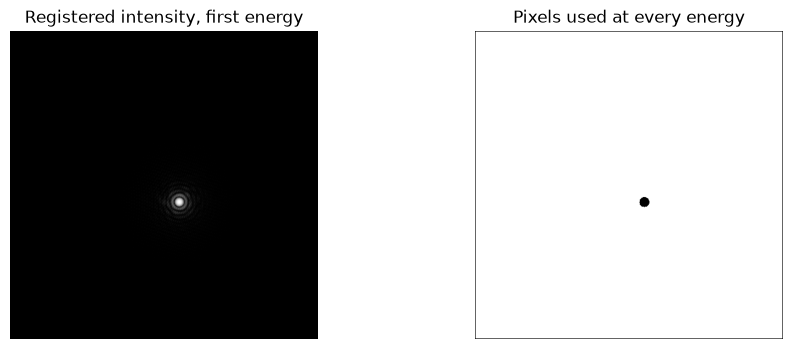

In [2]:
def energy_of(scan_id):
    with h5py.File(RAW / f'2409_maxiv_{scan_id:05d}.h5') as h:
        values = np.asarray(h[f'entry{scan_id}/measurement/pre_scan_snapshot/energy'][()]).ravel()
    if not len(values) or not np.allclose(values, values[0]):
        raise ValueError(f'Missing or varying energy in scan {scan_id}')
    return float(values[0])

def average(scan_id):
    with h5py.File(AVERAGES / f'scan_{scan_id:04d}_avg.h5') as h:
        image = np.asarray(h['image'][()]).squeeze()
    if image.ndim != 2:
        raise ValueError(f'Scan {scan_id} has shape {image.shape}')
    return image.astype(np.float32)

energies = np.array([energy_of(scan) for scan, _, _ in SCANS])
if len(np.unique(energies)) < 4 or np.any(energies <= 0):
    raise ValueError('At least four distinct positive energies are required')
reference_energy = float(np.median(energies))
first_shape = average(SCANS[0][0]).shape
if any(n % BINNING for n in first_shape):
    raise ValueError('Detector dimensions must be divisible by BINNING')
yy, xx = np.indices(first_shape, dtype=np.float32)
center = np.asarray(DETECTOR_CENTER, dtype=np.float32)
registered, valid_stack = [], []
dark_cache = {}
for (scan, dark_id, exposure), energy in zip(SCANS, energies):
    if dark_id not in dark_cache:
        dark_cache[dark_id] = average(dark_id)
    raw = average(scan)
    if raw.shape != first_shape or dark_cache[dark_id].shape != first_shape:
        raise ValueError(f'Image shape mismatch at scan {scan}')
    corrected = (raw - dark_cache[dark_id]) / (500 * exposure)
    source_valid = np.isfinite(corrected) & (raw < SATURATION)
    source_valid &= (yy-center[0])**2 + (xx-center[1])**2 > BEAMSTOP_RADIUS**2
    scale = reference_energy / energy
    coords = (center[0] + scale*(yy-center[0]), center[1] + scale*(xx-center[1]))
    image = map_coordinates(np.nan_to_num(corrected), coords, order=1, mode='constant', cval=0)
    # Interpolation must not touch an excluded source pixel.
    valid = map_coordinates(source_valid.astype(np.float32), coords, order=1, mode='constant', cval=0) > .999
    shape = (first_shape[0]//BINNING, BINNING, first_shape[1]//BINNING, BINNING)
    registered.append(image.reshape(shape).mean(axis=(1,3)))
    valid_stack.append(valid.reshape(shape).all(axis=(1,3)))
registered = np.stack(registered)
valid_stack = np.stack(valid_stack)
common_valid = valid_stack.all(axis=0)
print('Energy range:', energies.min(), energies.max(), 'eV; reference:', reference_energy, 'eV')
print('Registered shape:', registered.shape, 'common valid fraction:', common_valid.mean())
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].imshow(np.log1p(np.maximum(registered[0],0)), cmap='gray')
ax[0].set_title('Registered intensity, first energy')
ax[1].imshow(common_valid, cmap='gray')
ax[1].set_title('Pixels used at every energy')
for a in ax: a.axis('off')
plt.show()


## Fit the direct intensity model

For $f=u+iv$ and $z=CB^*$, the measured intensity is $|f|^2|C|^2+|B|^2+2u\operatorname{Re}z-2v\operatorname{Im}z$. This is linear in four real coefficients at each detector pixel. The columns of the spectral design matrix must have rank four. Negative fitted powers or failure of $|z|^2=|C|^2|B|^2$ indicate model mismatch or noise.


In [3]:
# Trial complex response only. Replace with a measured or physically justified f(E).
E0 = float(np.median(energies))
GAMMA_EV = float((energies.max()-energies.min()) / 5)
if GAMMA_EV <= 0: raise ValueError('Zero spectral width')
f = GAMMA_EV / (energies-E0 + 1j*GAMMA_EV) + 0.15j*((energies-E0)/(energies.max()-energies.min()))**2
design = np.column_stack([np.abs(f)**2, np.ones(len(f)), 2*f.real, -2*f.imag])
print('Design rank:', np.linalg.matrix_rank(design), 'condition number:', np.linalg.cond(design))
if np.linalg.matrix_rank(design) < 4 or np.linalg.cond(design) > 1e8:
    raise ValueError('Chosen spectral response cannot distinguish the four intensity terms')
observed = registered[:, common_valid].astype(np.float64)
coeff, _, _, _ = np.linalg.lstsq(design, observed, rcond=None)
power_C, power_B, real_z_twice, minus_imag_z_twice = coeff
z = (real_z_twice - 1j*minus_imag_z_twice)/2
identity_error = (np.abs(z)**2 - power_C*power_B) / np.maximum(np.abs(power_C*power_B), 1e-12)
print('Negative fitted power fractions:', np.mean(power_C<0), np.mean(power_B<0))
print('Median absolute amplitude identity error:', np.median(np.abs(identity_error)))
# Fix the per-pixel phase gauge with B real. Pixels with nonpositive B power remain invalid.
usable = (power_B > 0) & (power_C >= 0) & np.isfinite(identity_error)
B_values = np.sqrt(power_B[usable])
C_values = z[usable] / B_values
B = np.full(common_valid.shape, np.nan+0j)
C = np.full(common_valid.shape, np.nan+0j)
fit_mask = np.zeros(common_valid.shape, dtype=bool)
flat_indices = np.flatnonzero(common_valid)[usable]
B.flat[flat_indices], C.flat[flat_indices] = B_values, C_values
fit_mask.flat[flat_indices] = True
A = f[:,None,None] * C[None,:,:]
predicted = np.abs(A+B[None,:,:])**2
residual = registered[:,fit_mask] - predicted[:,fit_mask]
relative_rms = np.sqrt(np.mean(residual**2)) / max(np.sqrt(np.mean(registered[:,fit_mask]**2)),1e-12)
print('Usable pixels:', fit_mask.sum(), 'relative RMS intensity residual:', relative_rms)
if relative_rms > 0.2 or fit_mask.mean() < 0.5:
    print('WARNING: trial spectral model fails on these data; do not interpret A or B physically.')


Design rank: 4 condition number: 252.624294770204
Negative fitted power fractions: 0.94521059233664 0.0
Median absolute amplitude identity error: 3.297271841096723
Usable pixels: 14239 relative RMS intensity residual: 36.0193185078817


In [ ]:
fig,ax=plt.subplots()
crop=100
ax.imshow((np.abs(A[0])**2-np.abs(A[5])**2)[crop:-crop,crop:-crop])

IndexError: index 15 is out of bounds for axis 0 with size 13

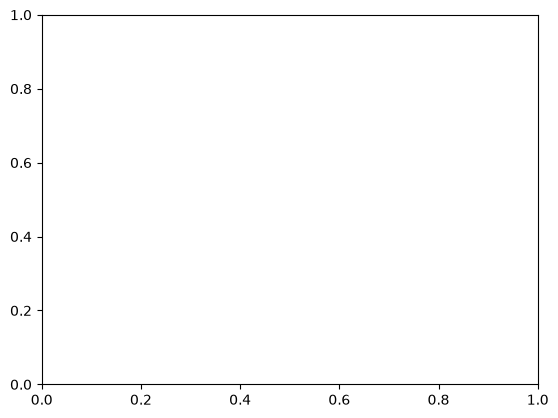

In [29]:
fig,ax=plt.subplots()
def reconstruct(im):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(im)))
crop=100
ax.imshow(np.abs(reconstruct(np.nan_to_num(0*np.abs(A[5])**2+np.abs(A[15])**2))), vmin=0, vmax=1e3)

/tmp/ipykernel_42828/1054797973.py:3: RuntimeWarning: Mean of empty slice
  np.nanmean(np.abs(A),axis=0), np.nanmean(np.abs(predicted-registered),axis=0)]


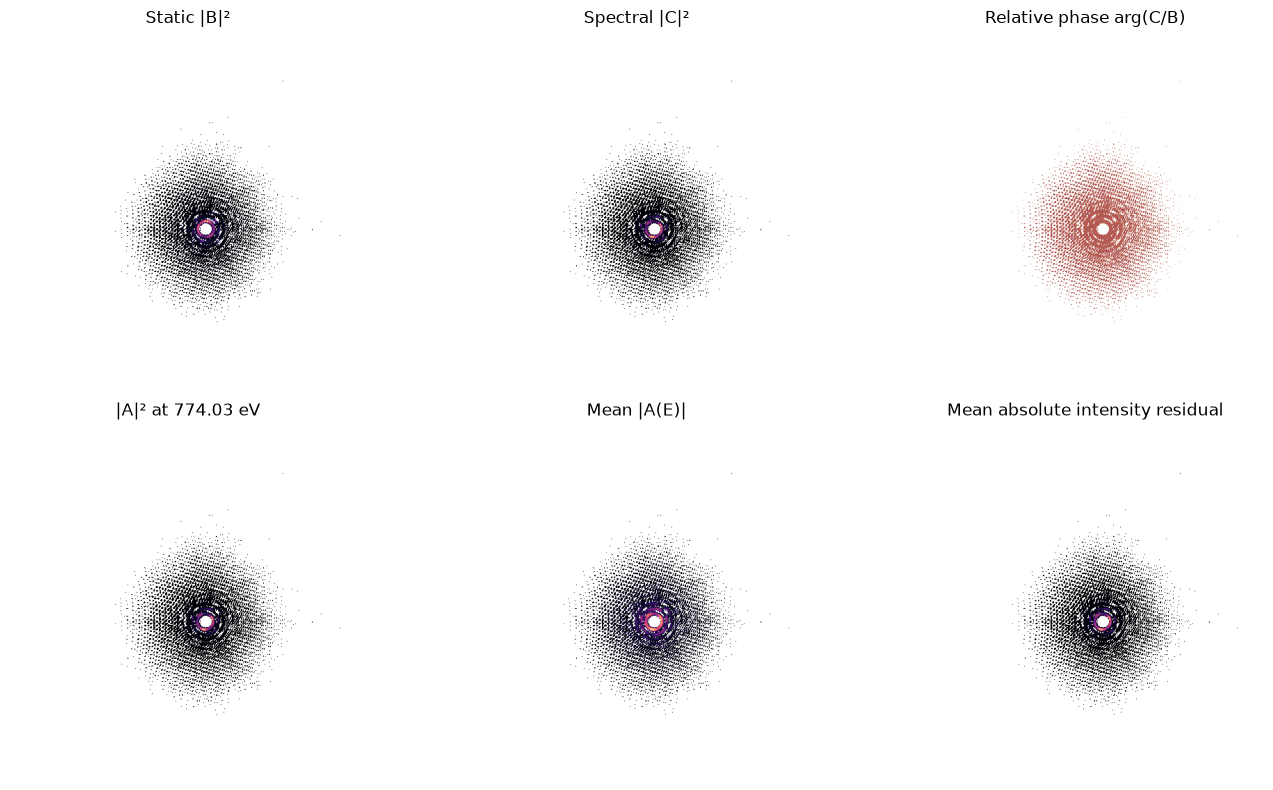

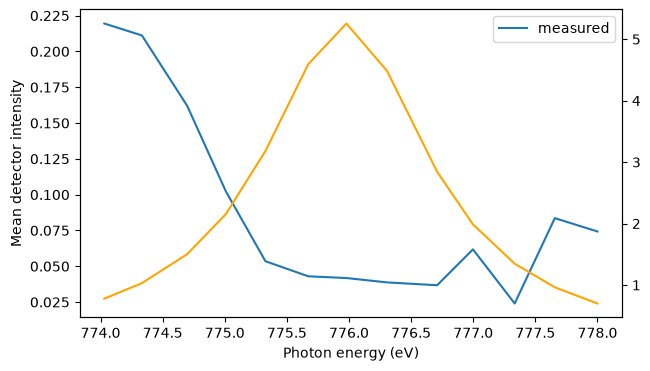

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(14,8))
images = [np.abs(B)**2, np.abs(C)**2, np.angle(C), np.abs(A[0])**2,
          np.nanmean(np.abs(A),axis=0), np.nanmean(np.abs(predicted-registered),axis=0)]
titles = ['Static |B|²','Spectral |C|²','Relative phase arg(C/B)',
          f'|A|² at {energies[0]:.2f} eV','Mean |A(E)|','Mean absolute intensity residual']
for a, image, title in zip(ax.flat, images, titles):
    a.imshow(image, cmap='twilight' if 'phase' in title else 'magma')
    a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(energies, np.nanmean(registered[:,fit_mask],axis=1), '-', label='measured')
ax2=ax.twinx()
ax2.plot(energies, np.nanmean(predicted[:,fit_mask],axis=1), '-', label='model', c="orange")
ax.set(xlabel='Photon energy (eV)', ylabel='Mean detector intensity')
ax.legend(); plt.show()

## Save the trial decomposition

The saved arrays are on the binned reference-energy detector grid. `A` and `B` are scattering amplitudes in a chosen phase gauge, not real-space reconstructions. Keep the assumed `spectral_response` and fit diagnostics with every result.


In [5]:
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
with h5py.File(OUTPUT, 'w') as h:
    h.attrs['model'] = 'I(E,q)=|f(E)C(q)+B(q)|^2'
    h.attrs['spectral_response_note'] = 'Illustrative Lorentzian plus curved background; replace before physical interpretation'
    h.attrs['reference_energy_eV'] = reference_energy
    h.attrs['binning'] = BINNING
    h.attrs['relative_rms_intensity_residual'] = relative_rms
    for name, data in {'energies_eV':energies, 'scan_ids':np.array(SCANS)[:,0].astype(int),
                       'spectral_response':f, 'registered_intensity':registered,
                       'common_valid':common_valid, 'fit_mask':fit_mask,
                       'B':B, 'C':C, 'A':A, 'predicted_intensity':predicted}.items():
        h.create_dataset(name, data=data, compression='gzip' if np.ndim(data)>1 else None)
print('Saved', OUTPUT)


Saved /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/maxiv_phase_test/processed/Logs/data_hologram_spectral_separation_maxiv.hdf5
